# Transfer Learning - CIFAR 10 (multi-class classifier)

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [14]:
import os

import tensorflow as tf
import keras
from keras import layers, optimizers, Model, metrics
import numpy as np
import matplotlib.pyplot as plt
import tensorflow_datasets as tfds

### Parameters and classes

In [4]:
BATCH_SIZE = 32
classes = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

## Take a look at the Dataset

In [5]:
(training_images, training_labels), (validation_images, validation_labels) = keras.datasets.cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step


### Visualization utilities 

In [ ]:
# utility to display training and validation curves
def plot_metrics(metric_name, title, ylim=1):
  plt.title(title)
  plt.ylim(0,ylim)
  plt.plot(history.history[metric_name],color='blue',label=metric_name)
  plt.plot(history.history['val_' + metric_name],color='green',label='val_' + metric_name)


def visualize_images(indices, images, labels, predictions=None):
    fig = plt.figure(figsize=(20,4))

    for i in range(len(indices)):
        image_index = indices[i]
        ax = fig.add_subplot(1,10,i+1)
        ax.imshow(images[image_index])
        ax.set_title(classes[int(labels[image_index])], pad=10, color="black")
        ax.axis("off")

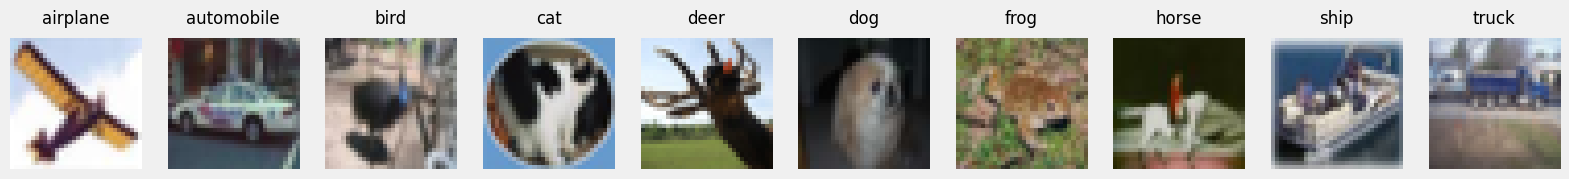

In [124]:
# Visualize 10 random images (one of each class)
random_indices = []
for label in range(10):
    all_indices = np.where(training_labels==label)[0]
    random_indices.append(int(np.random.choice(all_indices)))

visualize_images(random_indices, training_images, training_labels)

## Preprocessing data

In [7]:
def preprocess_for_resnet(images):
    images = images.astype("float32")
    output_images = keras.applications.resnet50.preprocess_input(images)
    return output_images

train_x = preprocess_for_resnet(training_images)
valid_x = preprocess_for_resnet(validation_images)

## Define the model (network with transfer learning)


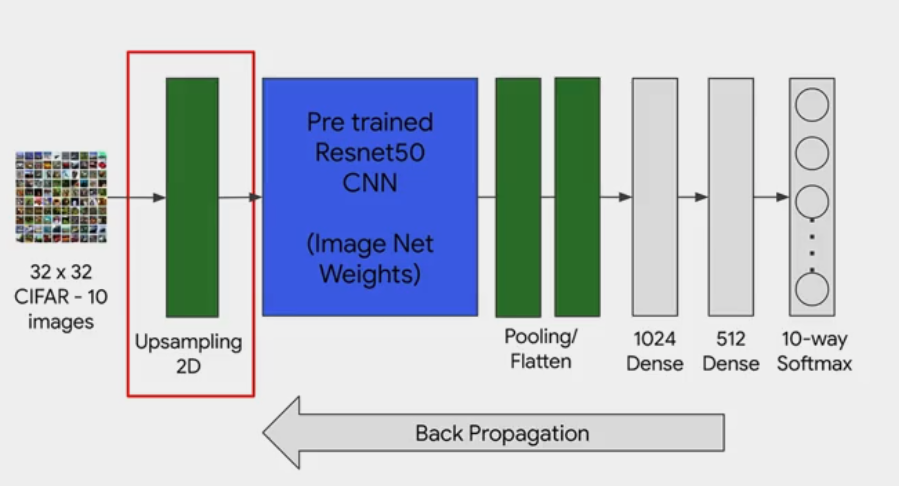

In [ ]:
# Define ResNet50 base model
def feature_extractor(inputs):
    resnet_base_model = keras.applications.resnet.ResNet50(input_shape = (224,224,3),
                                                           include_top=False,
                                                           weights="imagenet",
                                                           name="ResNet50_base_model")(inputs)
    return resnet_base_model

def classifier(inputs):
    x = keras.layers.GlobalAveragePooling2D()(inputs)
    x = keras.layers.Flatten()(x)
    x = keras.layers.Dense(1024, activation='relu')(x)
    x = keras.layers.Dense(512, activation='relu')(x)
    x = keras.layers.Dense(10, activation='softmax', name="Classification")(x)
    return x

def final_model(inputs):
    upsampled = keras.layers.UpSampling2D(size=(7,7))(inputs)
    base_model_output = feature_extractor(upsampled)
    final_output = classifier(base_model_output)
    return final_output


input_layer = keras.layers.Input(shape=(32,32,3))
output_layer = final_model(input_layer)
model = Model(inputs=input_layer, outputs=output_layer)

model.summary()

I0000 00:00:1776788574.404175      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ ResNet50_base_model             │ (None, 7, 7, 2048)     │    23,587,712 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │     2,098,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ Classification (Dense)          │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,215,818 (100.01 MB)

 Trainable params: 26,162,698 (99.80 MB)

 Non-trainable params: 53,120 (207.50 KB)

In [ ]:
# Compile the model

model.compile(optimizer='SGD',
              loss=keras.losses.SparseCategoricalCrossentropy(),
              metrics=['accuracy'])

In [ ]:
EPOCHS = 4
history = model.fit(train_x, training_labels,
                    epochs=EPOCHS,
                    validation_data=(valid_x, validation_labels),
                    batch_size=64)

Epoch 1/4


I0000 00:00:1776788590.387942     128 service.cc:152] XLA service 0x7eee840032a0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1776788590.387980     128 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0
I0000 00:00:1776788592.802456     128 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1776788613.470478     128 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


782/782 ━━━━━━━━━━━━━━━━━━━━ 257s 286ms/step - accuracy: 0.7580 - loss: 0.7437 - val_accuracy: 0.9157 - val_loss: 0.2427
Epoch 2/4
782/782 ━━━━━━━━━━━━━━━━━━━━ 204s 261ms/step - accuracy: 0.9661 - loss: 0.1063 - val_accuracy: 0.9431 - val_loss: 0.1686
Epoch 3/4
782/782 ━━━━━━━━━━━━━━━━━━━━ 204s 261ms/step - accuracy: 0.9903 - loss: 0.0365 - val_accuracy: 0.9495 - val_loss: 0.1656
Epoch 4/4
782/782 ━━━━━━━━━━━━━━━━━━━━ 204s 261ms/step - accuracy: 0.9968 - loss: 0.0142 - val_accuracy: 0.9526 - val_loss: 0.1663


In [87]:
loss, accuracy = model.evaluate(valid_x, validation_labels, batch_size=64)

157/157 ━━━━━━━━━━━━━━━━━━━━ 11s 72ms/step - accuracy: 0.9516 - loss: 0.1662


## Plot loss and accuracy curves

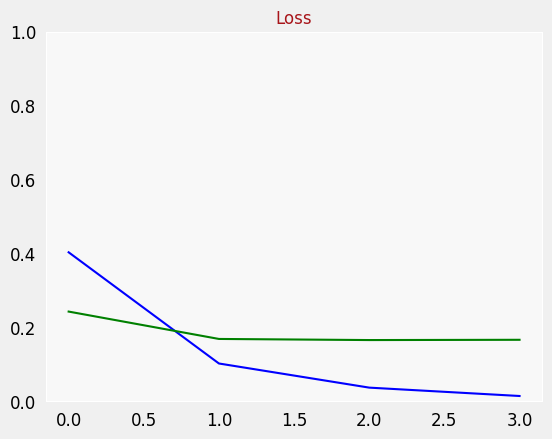

In [128]:
plot_metrics("loss", "Loss")

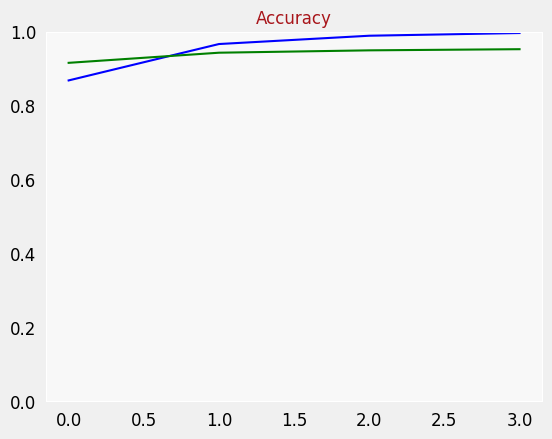

In [129]:
plot_metrics("accuracy", "Accuracy")

### Visualize unseen data & their predictions

In [115]:
#@title Visualization Utilities[RUN ME]
#Matplotlib config
plt.rc('image', cmap='gray')
plt.rc('grid', linewidth=0)
plt.rc('xtick', top=False, bottom=False, labelsize='large')
plt.rc('ytick', left=False, right=False, labelsize='large')
plt.rc('axes', facecolor='F8F8F8', titlesize="large", edgecolor='white')
plt.rc('text', color='a8151a')
plt.rc('figure', facecolor='F0F0F0')# Matplotlib fonts
MATPLOTLIB_FONT_DIR = os.path.join(os.path.dirname(plt.__file__), "mpl-data/fonts/ttf")
# utility to display a row of digits with their predictions
def display_images(digits, predictions, labels, title):

  n = 10

  indexes = np.random.choice(len(predictions), size=n)
  n_digits = digits[indexes]
  n_predictions = predictions[indexes]
  n_predictions = n_predictions.reshape((n,))
  n_labels = labels[indexes]

  fig = plt.figure(figsize=(20, 4))
  plt.title(title)
  plt.yticks([])
  plt.xticks([])

  for i in range(10):
    ax = fig.add_subplot(1, 10, i+1)
    class_index = n_predictions[i]
    plt.xlabel(classes[class_index])
    plt.xticks([])
    plt.yticks([])
    plt.imshow(n_digits[i])

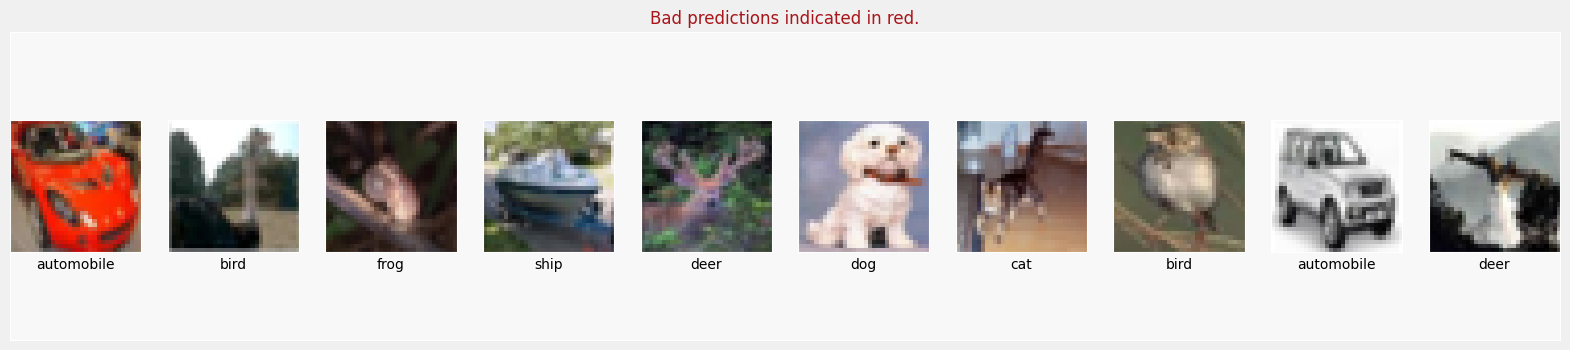

In [114]:
display_images(validation_images, probabilities, validation_labels, "Bad predictions indicated in red.")

157/157 ━━━━━━━━━━━━━━━━━━━━ 11s 70ms/step


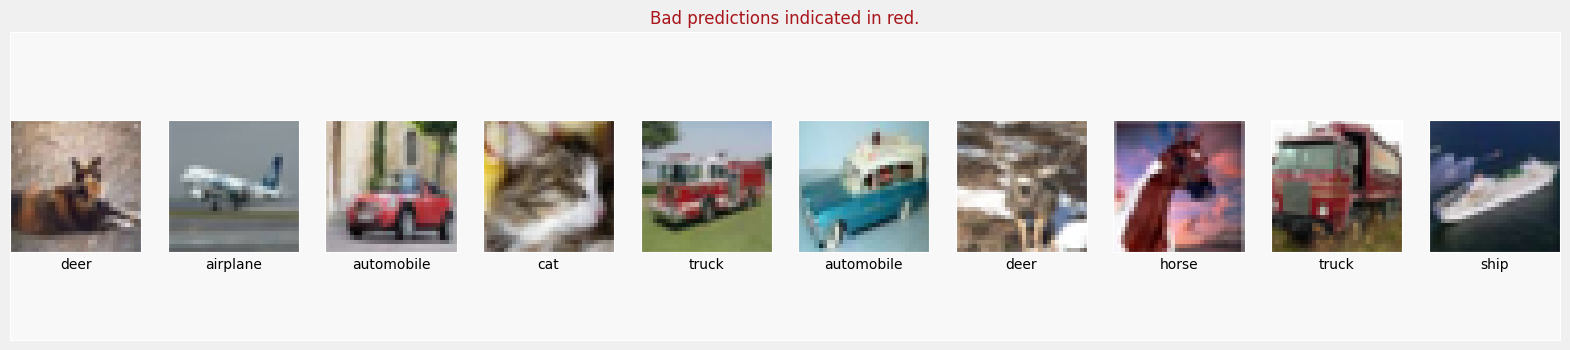

In [113]:
probabilities = model.predict(valid_x, batch_size=64)
probabilities = np.argmax(probabilities, axis = 1)

display_images(validation_images, probabilities, validation_labels, "Bad predictions indicated in red.")